# ATLAS tutorial: prepare Chile wind station climatology

This notebook reads wind station observations for Chile, cleans the time series, computes a monthly climatology, joins the results with station metadata and saves the final table as a CSV file.

It is designed as a step by step notebook for users who are not Python experts.

Normal users should only edit **Step 2**. All other cells can be run from top to bottom without changes.


## Step 1. Import required packages

Run this cell first.

If a package is missing, install it from a terminal or from a notebook cell. For example:

```bash
pip install pandas numpy matplotlib openpyxl geopandas
```

`geopandas` is only needed if you want to read and plot the shapefile.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Step 2. Input parameters

Edit only this section for normal use.

### Folder structure

Set `PROJECT_DIR` to the main folder that contains your input files and where you want to save the outputs.

The notebook uses relative paths from `PROJECT_DIR`, so it can be moved to another computer without changing all the code cells.

Expected input files:

```text
PROJECT_DIR/
├── Metadata_stations.xlsx
├── Wind_speed_database_1991_2026_ms.csv
├── Wind_direction_database_1991_2026.csv
└── REGIONES_v1.shp                 optional, only for plotting
```

### Component selection

Set `COMPONENT` to:

```python
"speed"
```

or:

```python
"direction"
```


In [2]:
# =========================
# MAIN FOLDER
# =========================

# Use a generic project folder. Change this path on your computer.
# Examples:
PROJECT_DIR = Path("../data/stations/chile")

# =========================
# INPUT FILES
# =========================

METADATA_FILE = PROJECT_DIR / "Metadata_stations.xlsx"
WIND_SPEED_FILE = PROJECT_DIR / "Wind_speed_database_1991_2026_ms.csv"
WIND_DIRECTION_FILE = PROJECT_DIR / "Wind_direction_database_1991_2026.csv"

# Optional shapefile used only for the map.
# If you do not have a shapefile, leave this path as None.
SHAPEFILE = "../data" / "shapefiles" / "chile" / "REGIONES_v1.shp"
# SHAPEFILE = None

# =========================
# OUTPUT FOLDER
# =========================

OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# ANALYSIS OPTIONS
# =========================

# Choose "speed" or "direction".
COMPONENT = "speed"

# Bounding box used to select the target area.
# Format required by this notebook: [lat_max, lon_min, lat_min, lon_max]
AREA = [-25.0, -109.8, -34.8, -77.8]

# Delete stations with more than this fraction of missing values.
# 0.95 means that stations with more than 95 percent missing data are removed.
MAX_NAN_FRACTION = 0.95

# Remove statistical outliers with the IQR method.
REMOVE_OUTLIERS = True


## Step 3. Functions

Run this cell without editing it.

The functions below:

1. check that the input parameters are valid;
2. read the metadata and wind data;
3. optionally read the shapefile;
4. clean the station time series;
5. calculate the monthly climatology;
6. merge the climatology with station coordinates and save the final output.


In [3]:
def validate_inputs(
    component,
    metadata_file,
    wind_speed_file,
    wind_direction_file,
    output_dir,
    area,
):
    """Validate the main user inputs before running the notebook."""
    component = component.lower().strip()

    if component not in {"speed", "direction"}:
        raise ValueError('COMPONENT must be either "speed" or "direction".')

    if not metadata_file.exists():
        raise FileNotFoundError(f"Metadata file not found: {metadata_file}")

    data_file = wind_speed_file if component == "speed" else wind_direction_file
    if not data_file.exists():
        raise FileNotFoundError(f"Wind data file not found: {data_file}")

    if len(area) != 4:
        raise ValueError("AREA must contain four values: [lat_max, lon_min, lat_min, lon_max].")

    output_dir.mkdir(parents=True, exist_ok=True)
    return component, data_file


def read_metadata(metadata_file):
    """Read station metadata and check the required columns."""
    metadata = pd.read_excel(metadata_file)

    required_columns = {"National Code", "Name", "latitude", "longitude", "altitud"}
    missing_columns = required_columns.difference(metadata.columns)

    if missing_columns:
        raise ValueError(
            "The metadata file is missing these required columns: "
            + ", ".join(sorted(missing_columns))
        )

    return metadata


def read_wind_data(data_file, component):
    """Read wind observations from CSV."""
    if component == "direction":
        return pd.read_csv(data_file, encoding="latin1")

    return pd.read_csv(data_file)


def read_shapefile_if_available(shapefile):
    """Read the optional shapefile if it exists."""
    if shapefile is None:
        print("No shapefile selected. The map will use only station points.")
        return None

    shapefile = Path(shapefile)
    if not shapefile.exists():
        print(f"Shapefile not found: {shapefile}")
        print("The workflow can continue without the shapefile.")
        return None

    import geopandas as gpd

    geometries = gpd.read_file(shapefile)
    return geometries.to_crs("EPSG:4326")


def filter_metadata_by_area(metadata, area):
    """Filter stations using a bounding box."""
    lat_max, lon_min, lat_min, lon_max = area

    return metadata[
        (metadata["longitude"] >= lon_min)
        & (metadata["longitude"] <= lon_max)
        & (metadata["latitude"] >= lat_min)
        & (metadata["latitude"] <= lat_max)
    ].copy()


def plot_stations(metadata, area=None, geometries=None):
    """Plot stations, optionally with administrative boundaries."""
    fig, ax = plt.subplots(figsize=(8, 6))

    if geometries is not None:
        geometries.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.8)

    ax.scatter(metadata["longitude"], metadata["latitude"], s=20)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Wind stations")

    if area is not None:
        lat_max, lon_min, lat_min, lon_max = area
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)

    plt.show()


def remove_outliers_iqr(df):
    """Replace outliers with NaN using the interquartile range method."""
    df_clean = df.copy()

    for column in df_clean.columns:
        q1 = df_clean[column].quantile(0.25)
        q3 = df_clean[column].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        df_clean[column] = df_clean[column].where(
            (df_clean[column] >= lower) & (df_clean[column] <= upper)
        )

    return df_clean


def clean_wind_data(df, max_nan_fraction=0.95, remove_outliers=True):
    """Prepare wind data for climatology calculation."""
    df = df.copy()

    if "Date" not in df.columns:
        raise ValueError('The wind CSV must contain a "Date" column.')

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"])
    df = df.set_index("Date").sort_index()
    df = df.apply(pd.to_numeric, errors="coerce")

    nan_fraction = df.isna().mean()
    columns_to_drop = nan_fraction[nan_fraction > max_nan_fraction].index.tolist()
    df = df.loc[:, nan_fraction <= max_nan_fraction]

    print(f"Deleted columns because of missing data: {len(columns_to_drop)}")
    if columns_to_drop:
        print(columns_to_drop)

    if remove_outliers:
        df = remove_outliers_iqr(df)

    return df


def calculate_monthly_climatology(df_clean):
    """Calculate the monthly climatology from daily and monthly means."""
    df_daily = df_clean.resample("D").mean()
    df_monthly = df_daily.resample("ME").mean()

    return df_monthly.groupby(df_monthly.index.month).mean()


def merge_climatology_with_metadata(df_clim, metadata, component):
    """Convert climatology to long format and add station metadata."""
    value_column = f"wind_{component}"

    df_wind = df_clim.copy().reset_index()
    df_wind = df_wind.rename(columns={"Date": "month", "index": "month"})

    df_wind_long = df_wind.melt(
        id_vars="month",
        var_name="station_raw",
        value_name=value_column,
    )

    df_wind_long["id"] = df_wind_long["station_raw"].str[:6].astype(int)
    df_wind_long["name_from_data"] = (
        df_wind_long["station_raw"]
        .str[7:]
        .str.replace("_", " ", regex=False)
    )

    df_final = (
        df_wind_long.drop(columns="name_from_data")
        .merge(
            metadata[["National Code", "Name", "latitude", "longitude", "altitud"]],
            left_on="id",
            right_on="National Code",
            how="left",
        )
        .drop(columns=["National Code"])
        .rename(columns={"Name": "name", "altitud": "altitude"})
    )

    return df_final[["month", "id", "name", "latitude", "longitude", "altitude", value_column]]


def save_output(df_final, output_dir, component, country="chile"):
    """Save the final table to CSV."""
    output_file = output_dir / f"allstats_wind_{component}_{country}.csv"
    df_final.to_csv(output_file, index=False)
    print(f"Saved output file: {output_file}")
    return output_file


## Step 4. Read inputs

Run this cell after checking the parameters in Step 2.

The cell loads station metadata, the selected wind data file and, if available, the shapefile.


In [4]:
COMPONENT, WIND_DATA_FILE = validate_inputs(
    component=COMPONENT,
    metadata_file=METADATA_FILE,
    wind_speed_file=WIND_SPEED_FILE,
    wind_direction_file=WIND_DIRECTION_FILE,
    output_dir=OUTPUT_DIR,
    area=AREA,
)

metadata = read_metadata(METADATA_FILE)
wind_data = read_wind_data(WIND_DATA_FILE, COMPONENT)
geometries = read_shapefile_if_available(SHAPEFILE)

print(f"Selected component: {COMPONENT}")
print(f"Metadata rows: {len(metadata)}")
print(f"Wind data shape: {wind_data.shape}")
metadata.head()


Shapefile not found: /mnt/DATA/PROGETTI/27_WMO_ATLAS/stations/chile/wind/REGIONES_v1.shp
The workflow can continue without the shapefile.
Selected component: speed
Metadata rows: 120
Wind data shape: (309535, 121)


,National Code,Name,latitude,longitude,altitud
0,170001,Visviri Tenencia,-17.59500,-69.47750,4084
1,180005,"Chacalluta, Arica Ap.",-18.35555,-70.34028,51
2,180017,Putre,-18.20000,-69.56250,3532
3,180018,"Defensa Civil, Arica",-18.49111,-70.30139,71
4,180042,"Cerro Sombrero, Arica",-18.51250,-70.26556,122


## Step 5. Check the station area

This step filters the metadata using the selected bounding box and plots the stations.

Use this step to check that `AREA` is correct before continuing.


Stations inside selected area: 4


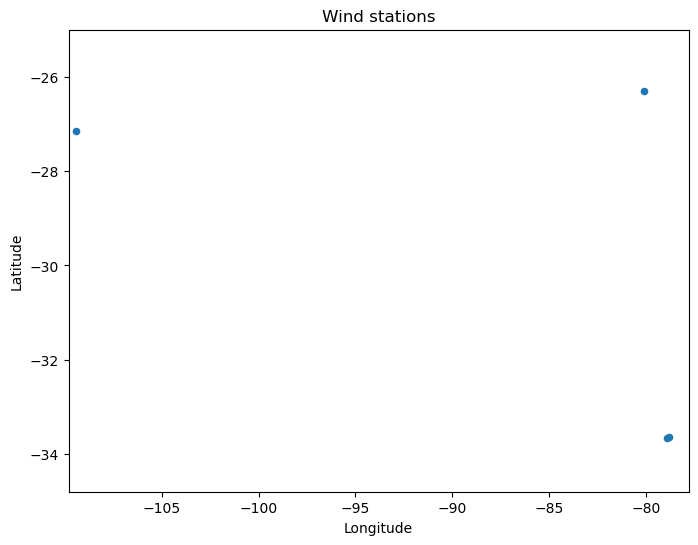

,National Code,Name,latitude,longitude,altitud
14,260007,Isla San Felix,-26.291388,-80.095277,44
15,270001,Mataveri Isla de Pascua Ap.,-27.158890,-109.432500,69
43,330031,"Juan Fernández, Estación Meteorológica.",-33.635830,-78.833050,40
44,330066,"La Punta, Juan Fernández Ad.",-33.666388,-78.931666,126


In [5]:
metadata_filtered = filter_metadata_by_area(metadata, AREA)

print(f"Stations inside selected area: {len(metadata_filtered)}")
plot_stations(metadata_filtered, area=AREA, geometries=geometries)
metadata_filtered.head()


## Step 6. Clean the wind data

This step:

1. converts the `Date` column to a datetime index;
2. converts station columns to numeric values;
3. removes stations with too many missing values;
4. optionally removes outliers using the IQR method.


In [6]:
wind_clean = clean_wind_data(
    wind_data,
    max_nan_fraction=MAX_NAN_FRACTION,
    remove_outliers=REMOVE_OUTLIERS,
)

print(f"Clean data shape: {wind_clean.shape}")
wind_clean.head()


Deleted columns because of missing data: 2
['350007_Punta_Carranza_faro', '360015_Isla_Quiriquina_faro']
Clean data shape: (309535, 118)


,170001_Visviri_Tenencia,180005_Chacalluta_Arica_Ap,180017_Putre,180018_Defensa_Civil_Arica,180042_Cerro_Sombrero_Arica,200006_Diego_Aracena_Iquique_Ap,200010_UNAP_Universidad_Arturo_Prat_Iquique,210901_Ollagüe,220002_El_Loa_Calama_Ad,230001_Cerro_Moreno_Antofagasta_Ap,...,510005_Teniente_Gallardo_Puerto_Natales_Ad,520006_Carlos_Ibañez_Punta_Arenas_Ap,520012_Instituto_de_la_Patagonia_Jorge_Schytte,520014_Punta_Arenas_Unidad_Aeropolicial,520015_Magallanes_Villa_Tehuelche,520030_Cerro_Sombrero_Estrecho_de_Magallanes,530005_Fuentes_Martínez_Porvenir_Ad,530008_Escuela_Alberto_Hurtado,540008_Pampa_Guanaco_Tierra_del_Fuego,550001_Guardiamarina_Zañartu_Pto_Williams_Ad
Date,,,,,,,,,,,,,,,,,,,,,
1991-01-01 00:00:00,NaN,4.1,NaN,NaN,NaN,6.7,NaN,NaN,9.3,2.6,...,NaN,4.1,NaN,NaN,NaN,NaN,5.1,NaN,NaN,NaN
1991-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,4.6,NaN,NaN,NaN,2.6,...,NaN,2.6,NaN,NaN,NaN,NaN,4.6,NaN,NaN,NaN
1991-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,2.6,NaN,NaN,NaN,2.1,...,NaN,1.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-01-01 03:00:00,NaN,5.1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,2.1,...,NaN,2.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,3.6,NaN,NaN,NaN,1.5,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 7. Calculate monthly climatology

This step calculates a monthly climatology for each station.

The output has one row for each month from 1 to 12.


In [7]:
wind_climatology = calculate_monthly_climatology(wind_clean)

print(f"Monthly climatology shape: {wind_climatology.shape}")
wind_climatology.head(12)


Monthly climatology shape: (12, 118)


,170001_Visviri_Tenencia,180005_Chacalluta_Arica_Ap,180017_Putre,180018_Defensa_Civil_Arica,180042_Cerro_Sombrero_Arica,200006_Diego_Aracena_Iquique_Ap,200010_UNAP_Universidad_Arturo_Prat_Iquique,210901_Ollagüe,220002_El_Loa_Calama_Ad,230001_Cerro_Moreno_Antofagasta_Ap,...,510005_Teniente_Gallardo_Puerto_Natales_Ad,520006_Carlos_Ibañez_Punta_Arenas_Ap,520012_Instituto_de_la_Patagonia_Jorge_Schytte,520014_Punta_Arenas_Unidad_Aeropolicial,520015_Magallanes_Villa_Tehuelche,520030_Cerro_Sombrero_Estrecho_de_Magallanes,530005_Fuentes_Martínez_Porvenir_Ad,530008_Escuela_Alberto_Hurtado,540008_Pampa_Guanaco_Tierra_del_Fuego,550001_Guardiamarina_Zañartu_Pto_Williams_Ad
Date,,,,,,,,,,,,,,,,,,,,,
1,2.323194,3.027140,2.044360,1.806124,1.620218,4.455961,0.940187,4.625981,7.475889,3.897290,...,7.586030,7.506518,4.450483,5.426938,4.924695,8.783391,7.328151,4.888342,6.237934,5.803240
2,2.234877,2.937655,2.050456,1.944179,1.637055,4.670240,0.879005,4.807010,7.280407,3.707298,...,6.443694,6.990536,3.930056,4.948106,4.542560,8.129161,6.876486,4.561411,5.592664,5.427236
3,2.064505,2.854515,2.122663,1.725874,1.530484,4.424862,0.933972,4.506543,7.100374,3.504599,...,6.132021,6.568057,3.512882,4.371565,4.179847,7.612849,6.615029,4.227478,5.187335,5.060978
4,2.016804,2.743787,2.755219,1.677589,1.508832,3.878434,1.001524,3.913756,6.996391,3.350183,...,5.086731,6.088517,3.507882,4.279241,3.614131,6.525503,6.035206,3.826888,4.458529,4.779487
5,1.867712,2.619853,2.945911,1.575557,1.328796,3.397645,1.087287,3.780728,6.949716,3.179600,...,3.897080,5.491543,3.002247,3.677947,3.066377,5.406146,5.363593,3.300439,3.605388,4.338055
6,1.847796,2.503132,2.976287,1.499020,1.295700,3.162816,1.244751,3.850004,6.986810,3.304814,...,3.745178,5.309191,2.994109,3.732112,2.686319,4.892493,5.097852,3.455738,2.987259,4.102016
7,2.042869,2.489968,3.030411,1.517861,1.338196,3.199962,1.416023,3.048182,7.123313,3.469548,...,4.302852,5.569419,3.136172,4.053990,3.035720,5.515568,5.327042,3.522873,3.718889,4.386370
8,2.267590,2.743025,3.142218,1.637623,1.352674,3.383323,1.627673,4.042288,7.263009,3.847434,...,4.585282,5.917112,3.495691,4.325891,3.520990,6.093312,5.823560,3.843053,3.934214,4.805231
9,2.272960,3.018086,3.005092,1.771860,1.448313,3.675436,1.589755,4.181022,7.390364,4.132790,...,5.557156,6.424107,3.906925,4.872105,4.262900,7.224696,6.496787,4.509315,4.969303,5.080896


## Step 8. Merge climatology with station metadata

This step converts the station table from wide to long format and adds station name, latitude, longitude and altitude.


In [8]:
wind_final = merge_climatology_with_metadata(
    df_clim=wind_climatology,
    metadata=metadata,
    component=COMPONENT,
)

# Keep only stations inside the selected area.
lat_max, lon_min, lat_min, lon_max = AREA
wind_final_area = wind_final[
    (wind_final["longitude"] >= lon_min)
    & (wind_final["longitude"] <= lon_max)
    & (wind_final["latitude"] >= lat_min)
    & (wind_final["latitude"] <= lat_max)
].copy()

print(f"Final rows before area filter: {len(wind_final)}")
print(f"Final rows after area filter: {len(wind_final_area)}")
wind_final_area.head()


Final rows before area filter: 1416
Final rows after area filter: 48


,month,id,name,latitude,longitude,altitude,wind_speed
168,1,260007,Isla San Felix,-26.291388,-80.095277,44,6.137398
169,2,260007,Isla San Felix,-26.291388,-80.095277,44,6.146204
170,3,260007,Isla San Felix,-26.291388,-80.095277,44,6.048730
171,4,260007,Isla San Felix,-26.291388,-80.095277,44,5.925175
172,5,260007,Isla San Felix,-26.291388,-80.095277,44,5.464835


## Step 9. Save the output CSV

Run this cell to save the final table.

The output file is saved in:

```text
PROJECT_DIR/outputs/
```


In [9]:
output_file = save_output(
    df_final=wind_final_area,
    output_dir=OUTPUT_DIR,
    component=COMPONENT,
    country="chile",
)

output_file


Saved output file: /mnt/DATA/PROGETTI/27_WMO_ATLAS/stations/chile/wind/outputs/allstats_wind_speed_chile.csv


PosixPath('/mnt/DATA/PROGETTI/27_WMO_ATLAS/stations/chile/wind/outputs/allstats_wind_speed_chile.csv')

## Notes for adapting this notebook

To reuse this notebook for another country or another station dataset:

1. change `PROJECT_DIR`;
2. update the input file names if needed;
3. update `AREA` using the format `[lat_max, lon_min, lat_min, lon_max]`;
4. check that the metadata file contains these columns: `National Code`, `Name`, `latitude`, `longitude`, `altitud`;
5. run all cells from top to bottom.

The notebook does not modify the original input files. It only creates a new CSV in the output folder.
